In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 584.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.6 MB/s eta 0:00:00


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Test (1).mp4 to Test (1) (1).mp4


Video found successfully!

STARTING: YOLOv10n
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/track
YOLOv10n completed!
Processing Time: 184.03 seconds

STARTING: YOLOv11n
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # gener

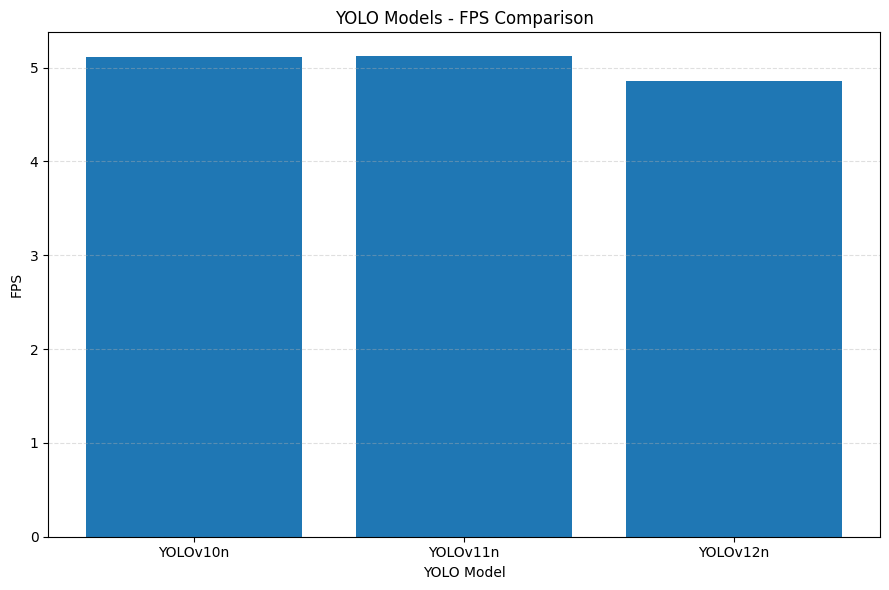

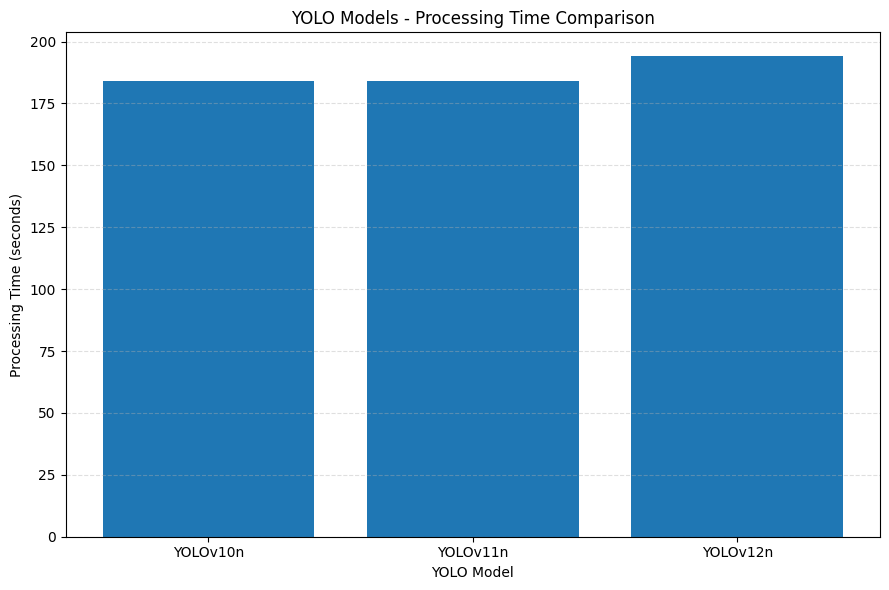


FINAL CONCLUSION
YOLOv11n achieved the highest FPS (5.12 FPS).
YOLOv11n achieved the lowest processing time (183.97 seconds).
Based on inference speed, YOLOv11n is the fastest model among the three models in this experiment.

ALL RESULTS SAVED
/content/YOLO_Results


In [4]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO



video_path = "/content/Test (1).mp4"

output_dir = "/content/YOLO_Results"

os.makedirs(output_dir, exist_ok=True)


#
if not os.path.exists(video_path):
    print("ERROR: Video file not found!")
    print("Expected path:", video_path)
    raise FileNotFoundError(video_path)

print("Video found successfully!")


# YOLOv10n

print("\n======================================")
print("STARTING: YOLOv10n")
print("======================================")

model10 = YOLO("yolov10n.pt")

start_time = time.perf_counter()

results10 = model10.track(
    source=video_path,
    persist=True,
    save=True,
    verbose=False
)

end_time = time.perf_counter()

processing_time_10 = end_time - start_time

print("YOLOv10n completed!")
print("Processing Time:",
      round(processing_time_10, 2),
      "seconds")


# YOLOv11n

print("\n======================================")
print("STARTING: YOLOv11n")
print("======================================")

model11 = YOLO("yolo11n.pt")

start_time = time.perf_counter()

results11 = model11.track(
    source=video_path,
    persist=True,
    save=True,
    verbose=False
)

end_time = time.perf_counter()

processing_time_11 = end_time - start_time

print("YOLOv11n completed!")
print("Processing Time:",
      round(processing_time_11, 2),
      "seconds")


# YOLOv12n

print("\n======================================")
print("STARTING: YOLOv12n")
print("======================================")

model12 = YOLO("yolo12n.pt")

start_time = time.perf_counter()

results12 = model12.track(
    source=video_path,
    persist=True,
    save=True,
    verbose=False
)

end_time = time.perf_counter()

processing_time_12 = end_time - start_time

print("YOLOv12n completed!")
print("Processing Time:",
      round(processing_time_12, 2),
      "seconds")


# Results returned by Ultralytics
frames_10 = len(results10)
frames_11 = len(results11)
frames_12 = len(results12)


#  CALCULATE FPS

fps_10 = frames_10 / processing_time_10

fps_11 = frames_11 / processing_time_11

fps_12 = frames_12 / processing_time_12


# CREATE RESULTS TABLE

data = {
    "Model": [
        "YOLOv10n",
        "YOLOv11n",
        "YOLOv12n"
    ],

    "Frames": [
        frames_10,
        frames_11,
        frames_12
    ],

    "Processing Time (s)": [
        processing_time_10,
        processing_time_11,
        processing_time_12
    ],

    "FPS": [
        fps_10,
        fps_11,
        fps_12
    ]
}


df = pd.DataFrame(data)


#  DISPLAY COMPARISON
print("\n======================================")
print("FINAL COMPARISON")
print("======================================")

print(
    df.to_string(index=False)
)


#  SAVE CSV
csv_path = os.path.join(
    output_dir,
    "YOLO_speed_comparison.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print("\nResults saved to:")
print(csv_path)


# FIND FASTEST MODEL

fastest_model = df.loc[
    df["FPS"].idxmax(),
    "Model"
]

highest_fps = df["FPS"].max()


fastest_time_model = df.loc[
    df["Processing Time (s)"].idxmin(),
    "Model"
]

lowest_time = df["Processing Time (s)"].min()


#  SPEED ANALYSIS

print("\n======================================")
print("SPEED ANALYSIS")
print("======================================")

print(
    f"Highest FPS: {fastest_model} "
    f"with {highest_fps:.2f} FPS"
)

print(
    f"Lowest Processing Time: "
    f"{fastest_time_model} "
    f"with {lowest_time:.2f} seconds"
)

plt.figure(figsize=(9, 6))

plt.bar(
    df["Model"],
    df["FPS"]
)

plt.xlabel("YOLO Model")
plt.ylabel("FPS")

plt.title(
    "YOLO Models - FPS Comparison"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

fps_graph_path = os.path.join(
    output_dir,
    "FPS_Comparison.png"
)

plt.savefig(
    fps_graph_path,
    dpi=300
)

plt.show()


# PROCESSING TIME GRAPH

plt.figure(figsize=(9, 6))

plt.bar(
    df["Model"],
    df["Processing Time (s)"]
)

plt.xlabel("YOLO Model")

plt.ylabel(
    "Processing Time (seconds)"
)

plt.title(
    "YOLO Models - Processing Time Comparison"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

time_graph_path = os.path.join(
    output_dir,
    "Processing_Time_Comparison.png"
)

plt.savefig(
    time_graph_path,
    dpi=300
)

plt.show()

print("\n======================================")
print("FINAL CONCLUSION")
print("======================================")

print(
    f"{fastest_model} achieved the highest FPS "
    f"({highest_fps:.2f} FPS)."
)

print(
    f"{fastest_time_model} achieved the lowest "
    f"processing time "
    f"({lowest_time:.2f} seconds)."
)

print(
    f"Based on inference speed, {fastest_model} "
    f"is the fastest model among the three models "
    f"in this experiment."
)

print("\n======================================")
print("ALL RESULTS SAVED")
print("======================================")

print(output_dir)